In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [1]:
#| echo: true
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import data
from skimage.transform import resize

Loading a data example.

In [9]:
#| echo: true
x_0 = data.astronaut().astype(np.float32) / 255.0
num_steps = 5
timesteps = np.linspace(0, 1, num_steps)

Creating degradation schemes.

In [10]:
#| echo: true
def degrade_blur(x, t, max_sigma=15.0):
    sigma = t * max_sigma
    if sigma == 0: return x
    return gaussian_filter(x, sigma=(sigma, sigma, 0))

def degrade_pixelate(x, t, min_res=4):
    if t == 0: return x
    h, w, c = x.shape

    curr_h = max(min_res, int(h * (1 - t) + min_res * t))
    curr_w = max(min_res, int(w * (1 - t) + min_res * t))

    downsampled = resize(x, (curr_h, curr_w), order=0, anti_aliasing=False)
    return resize(downsampled, (h, w), order=0, anti_aliasing=False)

def degrade_mask(x, t):
    if t == 0: return x
    h, w, c = x.shape
    mask_size_h = int(h * t)
    mask_size_w = int(w * t)

    start_y = (h - mask_size_h) // 2
    start_x = (w - mask_size_w) // 2

    x_t = x.copy()
    x_t[start_y:start_y+mask_size_h, start_x:start_x+mask_size_w, :] = 0.5
    return x_t

Plot the degradation schemes.

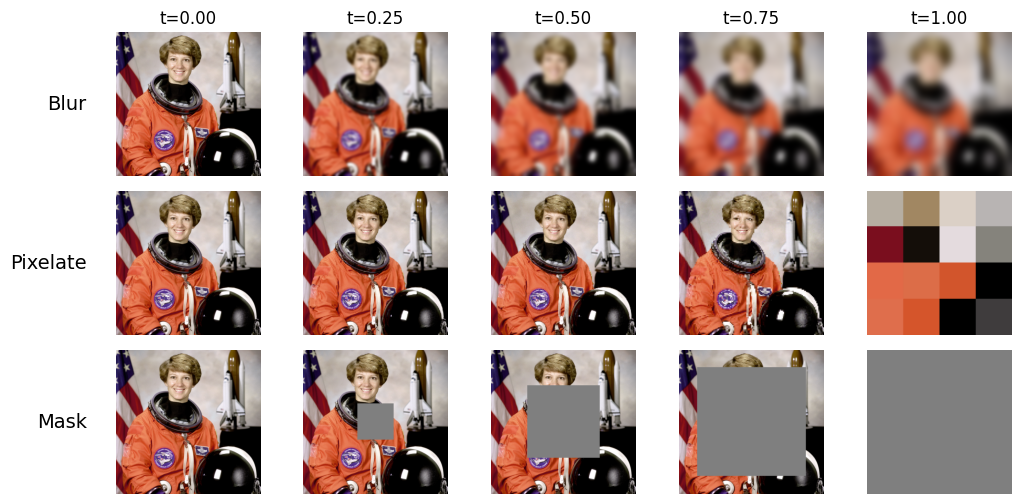

In [11]:
#| echo: true
fig, axes = plt.subplots(3, num_steps, figsize=(12, 6))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

for i, t in enumerate(timesteps):
    blur_t = degrade_blur(x_0, t)
    pix_t = degrade_pixelate(x_0, t)
    mask_t = degrade_mask(x_0, t)

    axes[0, i].imshow(blur_t)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title(f"t={t:.2f}", fontsize=12)
    else: axes[0, i].set_title(f"t={t:.2f}", fontsize=12)

    axes[1, i].imshow(pix_t)
    axes[1, i].axis('off')

    axes[2, i].imshow(mask_t)
    axes[2, i].axis('off')

axes[0, 0].text(-0.2, 0.5, 'Blur', va='center', ha='right', transform=axes[0, 0].transAxes, fontsize=14)
axes[1, 0].text(-0.2, 0.5, 'Pixelate', va='center', ha='right', transform=axes[1, 0].transAxes, fontsize=14)
axes[2, 0].text(-0.2, 0.5, 'Mask', va='center', ha='right', transform=axes[2, 0].transAxes, fontsize=14)

plt.show()